In [15]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Load the dataset
data = pd.read_csv("data/superstore.csv")

# Quick look
data.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [16]:
# Basic info
data.info()

# Check missing values
print("\nMissing values per column:\n", data.isnull().sum())

# Remove duplicates
data.drop_duplicates(inplace=True)

# Summary statistics
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB

Missing values per column:
 Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Catego

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [17]:
data['Category'].unique()
data['Region'].unique()


array(['South', 'West', 'Central', 'East'], dtype=object)

In [18]:
print("Total Sales:", data['Sales'].sum())
print("Total Profit:", data['Profit'].sum())
print("Average Discount:", data['Discount'].mean())


Total Sales: 2296195.5903
Total Profit: 286241.42260000005
Average Discount: 0.15627844041294978


/var/folders/v6/0z1tljn97rb81vctlpy47bh00000gn/T/ipykernel_65669/951244696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette="viridis")


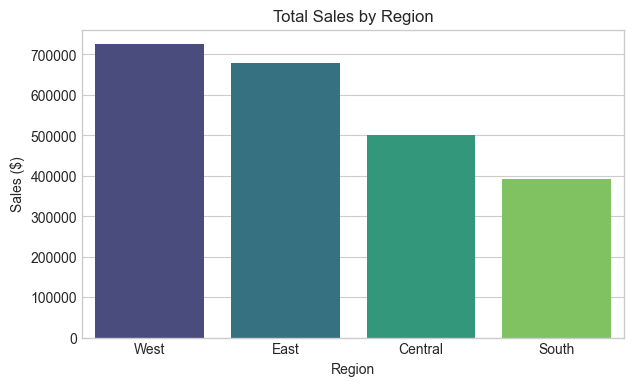

In [19]:
region_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="viridis")
plt.title("Total Sales by Region")
plt.ylabel("Sales ($)")
plt.show()


/var/folders/v6/0z1tljn97rb81vctlpy47bh00000gn/T/ipykernel_65669/2077508089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_profit.index, y=cat_profit.values, palette="pastel")


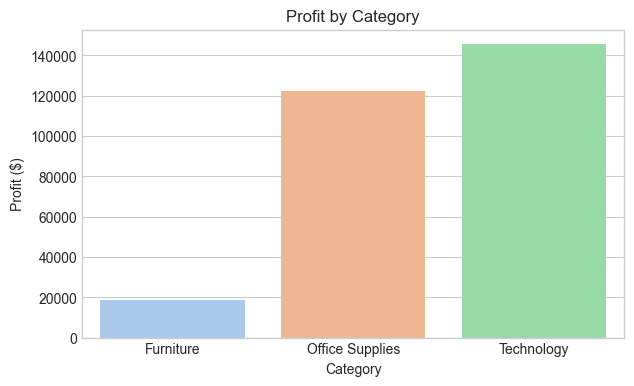

In [20]:
cat_profit = data.groupby('Category')['Profit'].sum()
plt.figure(figsize=(7,4))
sns.barplot(x=cat_profit.index, y=cat_profit.values, palette="pastel")
plt.title("Profit by Category")
plt.ylabel("Profit ($)")
plt.show()


/var/folders/v6/0z1tljn97rb81vctlpy47bh00000gn/T/ipykernel_65669/4154694888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcats.values, y=top_subcats.index, palette="crest")


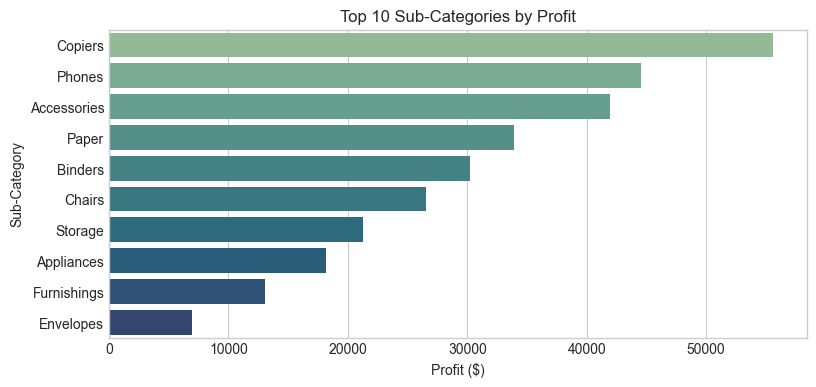

In [21]:
top_subcats = data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,4))
sns.barplot(x=top_subcats.values, y=top_subcats.index, palette="crest")
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Profit ($)")
plt.show()


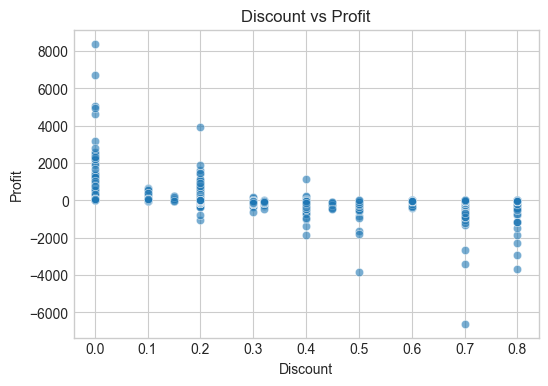

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Profit', data=data, alpha=0.6)
plt.title("Discount vs Profit")
plt.show()


In [23]:
data.to_csv("data/superstore_clean.csv", index=False)


Example conclusions:
The West region generates the highest sales.
Office Supplies often yield lower profit margins.
High discounts generally reduce profit.
A few sub-categories dominate total profit (e.g., Chairs, Phones).